# Importing the data

In [46]:
%pip install ucimlrepo
# Add this pip to the requirements folder which should also include Python version
from ucimlrepo import fetch_ucirepo 
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
  
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 
  
# data (as pandas dataframes) 
data = online_retail.data.original 

Note: you may need to restart the kernel to use updated packages.


In [60]:
df = duckdb.sql(
'''
WITH RECURSIVE online_retail AS (
    SELECT
        b.Country                                                   AS country,
        b.Description                                               AS description,
        b.Quantity                                                  AS quantity,
        CAST(STRPTIME(b.InvoiceDate, '%m/%d/%Y %H:%M') AS DATE)     AS invoice_date,
        MIN(invoice_date) OVER(PARTITION BY CustomerID)             AS first_purchase_date,
        b.UnitPrice                                                 AS unit_price,
        CAST(b.CustomerID AS STRING)                                AS customer_id,
        b.InvoiceNo                                                 AS invoice_number,
        b.Quantity * b.UnitPrice                                    AS order_value
    FROM
        data b
    WHERE 
        customer_id IS NOT NULL
),

snapshots AS (
    -- Anchor member - first date in dataset: 1/10/2010
    SELECT
        MIN(invoice_date) AS snapshot,
        MAX(invoice_date) AS max_date
    FROM 
        online_retail

    UNION ALL

    -- Recursive Member
    SELECT
        DATE_ADD(snapshot, INTERVAL 2 MONTH) AS snapshot,
        max_date
    FROM 
        snapshots
    WHERE
        DATE_ADD(snapshot, INTERVAL 2 MONTH) <= max_date
),

customer_snapshots AS (
    SELECT 
        s.snapshot,
        c.customer_id
    FROM 
        snapshots s
    CROSS JOIN 
        (SELECT DISTINCT customer_id FROM online_retail) c
),

cleaned_transactions AS (
    SELECT
        customer_id,
        invoice_number,
        invoice_date,
        description,
        order_value,
        quantity,
        CASE WHEN description = 'Discount' THEN 1 ELSE 0 END AS is_discount,
        CASE WHEN description = 'Discount' THEN order_value ELSE 0 END AS discount_value,
        CASE WHEN quantity < 0 THEN 1 ELSE 0 END AS is_return,
        CASE WHEN quantity < 0 THEN order_value * -1 ELSE 0 END AS returns_value,
        CASE WHEN ASCII(description) = ASCII(UPPER(description)) THEN 1 ELSE 0 END AS is_product
    FROM
        online_retail
),

snapshot_behaviour AS (
    SELECT 
        s.snapshot, 
        s.customer_id,
        SUM(c.order_value)                                                      AS snapshot_order_value,
        COUNT(DISTINCT c.invoice_number)                                        AS snapshot_orders_placed,
        SUM(c.order_value) / COUNT(DISTINCT c.invoice_number)                   AS snapshot_avg_order_value,
        COUNT(DISTINCT CASE WHEN c.is_discount = 1 THEN c.invoice_number END)   AS snapshot_total_discounts,
        COUNT(DISTINCT CASE WHEN c.is_return = 1 THEN c.invoice_number END)     AS snapshot_orders_returned,
        COUNT(DISTINCT CASE WHEN c.is_product = 1 THEN c.description END)       AS snapshot_unique_products_ordered,
        SUM(c.discount_value)                                                   AS snapshot_discount_value,
        SUM(c.returns_value)                                                    AS snapshot_returns_value,
    FROM
        customer_snapshots s
    LEFT JOIN
        cleaned_transactions c 
        ON c.customer_id = s.customer_id
        AND c.invoice_date >= s.snapshot  
        AND c.invoice_date < DATE_ADD(s.snapshot, INTERVAL 2 MONTH) -- Looking at only the current snapshot
    GROUP BY
        s.snapshot,
        s.customer_id
),

customer_history AS (
    SELECT
        s.snapshot, 
        s.customer_id,
        SUM(c.order_value)                                                      AS total_order_value,
        COUNT(DISTINCT c.invoice_number)                                        AS total_orders_placed,
        SUM(c.order_value) / COUNT(DISTINCT c.invoice_number)                   AS historic_avg_order_value,
        COUNT(DISTINCT CASE WHEN c.is_discount = 1 THEN c.invoice_number END)   AS total_discounts,
        COUNT(DISTINCT CASE WHEN c.is_return = 1 THEN c.invoice_number END)     AS total_orders_returned,
        COUNT(DISTINCT CASE WHEN c.is_product = 1 THEN c.description END)       AS unique_products_ordered,
        SUM(c.discount_value)                                                   AS total_discount_value,
        SUM(c.returns_value)                                                    AS total_returns_value
    FROM
        customer_snapshots s
    LEFT JOIN
        cleaned_transactions c
        ON c.customer_id = s.customer_id
        AND c.invoice_date < s.snapshot -- Looking at behaviour in all previous snapshots
    GROUP BY
        s.snapshot,
        s.customer_id
)

SELECT
    COALESCE(a.customer_id, b.customer_id) AS customer_id,
    COALESCE(a.snapshot, b.snapshot) AS snapshot,

    a.total_order_value,
    a.total_orders_placed,
    a.historic_avg_order_value,
    a.total_discounts,
    a.total_orders_returned,
    a.unique_products_ordered,
    a.total_discount_value,
    a.total_returns_value,

    b.snapshot_order_value,
    b.snapshot_orders_placed,
    b.snapshot_avg_order_value,
    b.snapshot_total_discounts,
    b.snapshot_orders_returned,
    b.snapshot_unique_products_ordered,
    b.snapshot_discount_value,
    b.snapshot_returns_value,

-- Churn Flag: 1 if the NEXT snapshot period has ZERO or NULL orders
CASE 
    WHEN COALESCE(LEAD(snapshot_orders_placed, 1) OVER (
        PARTITION BY customer_id 
        ORDER BY snapshot
    ), 0) = 0 THEN 1 
    ELSE 0 
END AS customer_churned
FROM
    customer_history a 
LEFT JOIN
    snapshot_behaviour b USING(snapshot, customer_id)

QUALIFY LAG(snapshot_orders_placed, 1, 1) OVER (
    PARTITION BY customer_id
    ORDER BY snapshot
) > 0
'''
).df()

df = df.fillna(0)

df["snapshot"] = pd.to_datetime(df["snapshot"])
df = df.sort_values(["customer_id", "snapshot"])

rev_rank = df.groupby("customer_id").cumcount(ascending=False)

test = df[rev_rank == 1]
train = df[rev_rank >= 1]

features = [
    "total_order_value",
    "total_orders_placed",
    "historic_avg_order_value",
    "total_discounts",
    "total_orders_returned",
    "unique_products_ordered",
    "total_discount_value",
    "total_returns_value",
    "snapshot_order_value",
    "snapshot_orders_placed",
    "snapshot_avg_order_value",
    "snapshot_total_discounts",
    "snapshot_orders_returned",
    "snapshot_unique_products_ordered",
    "snapshot_discount_value",
    "snapshot_returns_value",
]

X_train = train[features].to_numpy()
X_test = test[features].to_numpy()

y_train = train['customer_churned']
y_test = test['customer_churned']

print(X_train.shape)
print(X_test.shape)

(10313, 16)
(4331, 16)


# Investigating Features

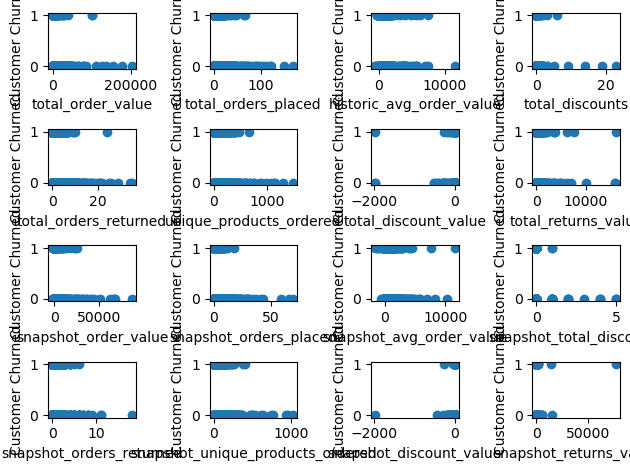

In [61]:
m,n = X_train.shape

figure, axes = plt.subplots(4, 4)
axes = axes.flatten()

for i in range(n):
    axes[i].scatter(X_train[:,i], y_train)
    axes[i].set_xlabel(features[i])
    axes[i].set_ylabel('Customer Churned')

plt.tight_layout()
plt.show()

# Investigating collinearity

In [62]:
# Investigating colinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

x = df[features].copy()
x = x.astype(float)
x = add_constant(x)

df_vif = pd.DataFrame({
    'Feature' : x.columns,
    'VIF' : [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
})

df_vif = df_vif[df_vif['Feature'] != 'const'].reset_index(drop=True)

print(df_vif)

                             Feature       VIF
0                  total_order_value  2.577823
1                total_orders_placed  6.712588
2           historic_avg_order_value  1.551334
3                    total_discounts  1.855728
4              total_orders_returned  3.574775
5            unique_products_ordered  3.194921
6               total_discount_value  1.180617
7                total_returns_value  1.071720
8               snapshot_order_value  2.872813
9             snapshot_orders_placed  5.180072
10          snapshot_avg_order_value  1.911693
11          snapshot_total_discounts  1.833517
12          snapshot_orders_returned  2.465963
13  snapshot_unique_products_ordered  3.350198
14           snapshot_discount_value  1.190313
15            snapshot_returns_value  1.017416


# Logistic Regression

Accuracy: 0.6663434500145448
Actual: 6361     1
8316     1
8317     0
8318     0
8319     0
        ..
3463     0
3464     0
3465     0
13823    1
13824    1
Name: customer_churned, Length: 10313, dtype: int32
Predicted: [1 0 0 ... 0 1 0]

total_order_value: 0.0
total_orders_placed: -0.06451900774368377
historic_avg_order_value: -0.6863625180915299
total_discounts: -0.6497690040674633
total_orders_returned: -0.17712623628306506
unique_products_ordered: -0.22475916909545365
total_discount_value: -0.49459146522749053
total_returns_value: 0.10834341977164003
snapshot_order_value: 0.10523822738809789
snapshot_orders_placed: -0.6871503878486737
snapshot_avg_order_value: -0.4988646127665528
snapshot_total_discounts: 0.1490567115801585
snapshot_orders_returned: -0.22570892976778814
snapshot_unique_products_ordered: 0.16554665168946203
snapshot_discount_value: -0.10009057146149697
snapshot_returns_value: 0.059878717518201556


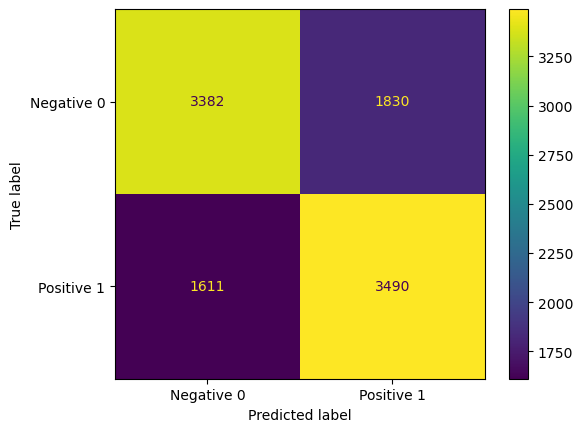

In [71]:
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, precision_recall_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay

scaler = StandardScaler()
poly = PolynomialFeatures(degree=3)
logr = linear_model.LogisticRegression()

def transform(X):
    X_poly = poly.fit_transform(X)
    X_poly_scaled = scaler.fit_transform(X_poly)

    return X_poly_scaled

# Transforming data
X_train_poly = transform(X_train)

# Training the model
logr_poly = linear_model.LogisticRegression(max_iter=2000, C=0.1, random_state=42)
logr_poly.fit(X_train_poly, y_train)

def evaluate(y_train, y_pred, logr):
    print(f'Accuracy: {accuracy_score(y_train, y_pred)}')
    print(f'Actual: {y_train}\nPredicted: {y_pred}\n')

    j = 0
    for col in features:
        print(f'{col}: {logr.coef_[0][j]}')
        j += 1

    matrix = confusion_matrix(y_train, y_pred)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=matrix, 
                                        display_labels= ['Negative 0', 'Positive 1'])
    cm_display.plot()

# Predicitions
y_pred_poly = logr_poly.predict(X_train_poly)
y_pred_poly_proba = logr_poly.predict_proba(X_train_poly)[:, 1]

# Evaluating model performance
evaluate(y_train, y_pred_poly, logr_poly)

Accuracy: 0.6026321865619949
Actual: 6361     1
8320     0
8324     0
760      1
6363     0
        ..
8314     0
758      1
5365     1
3465     0
13824    1
Name: customer_churned, Length: 4331, dtype: int32
Predicted: [1 0 0 ... 1 0 0]

total_order_value: 0.0
total_orders_placed: -0.06451900774368377
historic_avg_order_value: -0.6863625180915299
total_discounts: -0.6497690040674633
total_orders_returned: -0.17712623628306506
unique_products_ordered: -0.22475916909545365
total_discount_value: -0.49459146522749053
total_returns_value: 0.10834341977164003
snapshot_order_value: 0.10523822738809789
snapshot_orders_placed: -0.6871503878486737
snapshot_avg_order_value: -0.4988646127665528
snapshot_total_discounts: 0.1490567115801585
snapshot_orders_returned: -0.22570892976778814
snapshot_unique_products_ordered: 0.16554665168946203
snapshot_discount_value: -0.10009057146149697
snapshot_returns_value: 0.059878717518201556


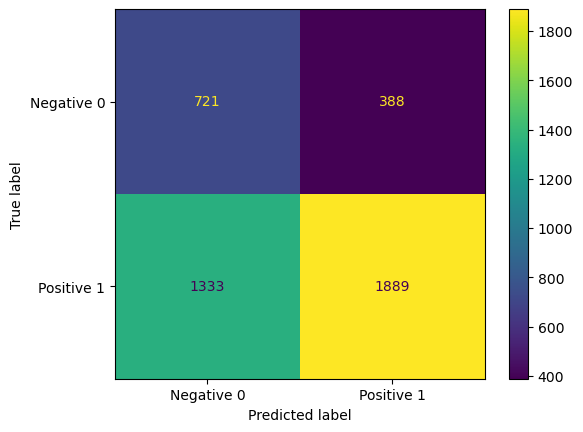

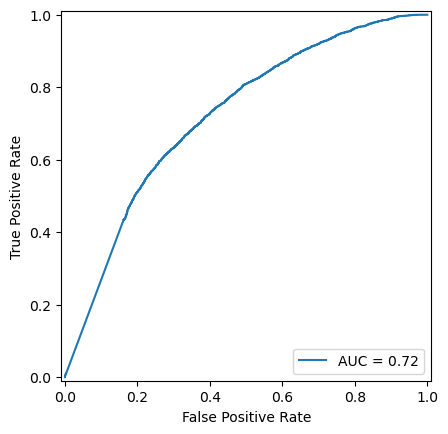

In [75]:
X_test_poly = poly.fit_transform(X_test)
X_test_poly = scaler.fit_transform(X_test_poly)
y_pred_poly = logr_poly.predict(X_test_poly)

evaluate(y_test, y_pred_poly, logr_poly)

fpr, tpr, thresholds = roc_curve(y_train, y_pred_poly_proba)
roc_auc = auc(fpr, tpr)
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
roc_display.plot()

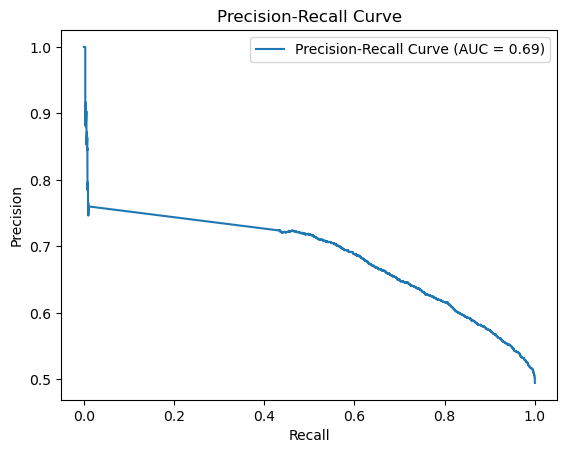

In [76]:
precision, recall, thresholds = precision_recall_curve(y_train, y_pred_poly_proba)
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()